In [11]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
!python --version

Python 3.12.3


In [13]:
import sys
import os

# Add project root, which is one level up the notebook folder, in the main dir
sys.path.append(os.path.abspath(".."))

# then bc we ran uv add --dev --editable, we can import the src package
import src.data_preperation as prep
print("Import successful!")

Import successful!


In [5]:
data_path = "../cache/UCI HAR Dataset/"

features = pd.read_csv(os.path.join(data_path, 'features.txt'), 
                       sep=r'\s+', header=None, names=['ID', 'FeatureName'])

X_train = pd.read_csv(os.path.join(data_path, 'train/X_train.txt'), 
                      sep=r'\s+', header=None)
X_train.columns = features['FeatureName']

X_train

FeatureName,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.070157,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,0.165259,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.195034,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,0.013865,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339


In [14]:
# default uses pearson, can only detect linear relationships, but is more straightforward
corr_matrix = X_train.corr()

g = sns.clustermap(corr_matrix, 
                   annot=False,       # set to false when using all 561 features to avoid clutter
                   cmap='coolwarm',
                   vmin=-1, vmax=1,  #Ensure the scale is anchored at -1 and 1
                   figsize=(12, 12))

# 3. Adjust plot labels
plt.title("Clustermap of 561 Sensor Feature Correlations", y=1.05)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.show()

NameError: name 'X_train' is not defined

In [4]:
# Die Labels (Antworten) laden
y_train = pd.read_csv(os.path.join(data_path, 'train/y_train.txt'), 
                      sep=r'\s+', header=None, names=['ActivityID'])

# Schauen, wie die Verteilung aussieht
print(y_train['ActivityID'].value_counts())

ActivityID
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


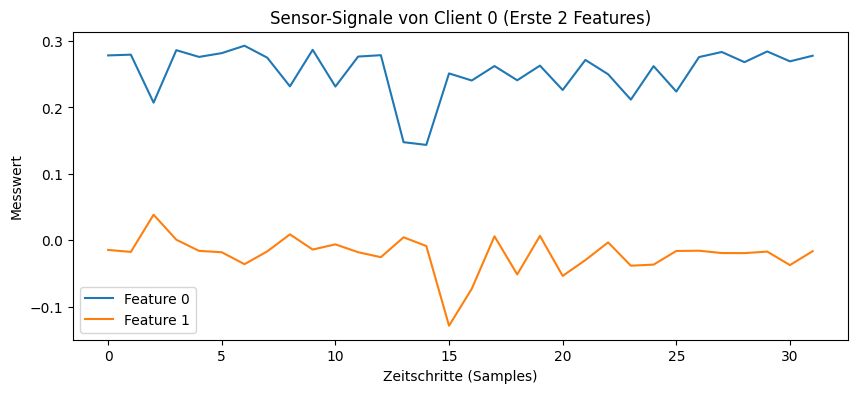

In [16]:

import sys
import os

# Hauptverzeichnis
root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# zum syspath hinzufuegen
if root not in sys.path:
    sys.path.append(root)

from src.data_loader import get_client_loader


loader = get_client_loader(client_id=0, batch_size=32)

#holt sich batch und nimmt erstes paket. 
X_batch, y_batch = next(iter(loader))

# plotten
plt.figure(figsize=(10, 4))
plt.plot(X_batch[:100, 0:2]) # Jetzt kennt Python 'X_batch'
plt.title("Sensor-Signale von Client 0 (Erste 2 Features)")
plt.xlabel("Zeitschritte (Samples)")
plt.ylabel("Messwert")
plt.legend(["Feature 0", "Feature 1"])
plt.show()